# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Ida Bagus Komang Adi Prayista
- **Email:** cybermoon3@gmail.com
- **ID Dicoding:** gusmang_adi

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana tren konsentrasi rata-rata PM2.5 per tahun dan per musim di seluruh 12 stasiun pemantauan kota Beijing selama periode Maret 2013 hingga Februari 2017, dan pada tahun serta musim manakah rata-rata PM2.5 mencapai nilai tertingginya?
- **Pertanyaan 2:** Stasiun pemantauan mana yang mencatat rata-rata konsentrasi PM2.5 tertinggi dan terendah di kota Beijing selama periode Maret 2013 hingga Februari 2017, dan berapa besar selisih rata-rata PM2.5 antara stasiun terpolusi dan stasiun terbersih?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid', palette='muted')

## Data Wrangling

### Gathering Data

Dataset Air Quality terdiri dari 12 file CSV, masing-masing merepresentasikan data kualitas udara dari satu stasiun pemantauan di Beijing, China. Data mencakup periode **Maret 2013 hingga Februari 2017**. 

Setiap file berisi pengukuran polutan udara (PM2.5, PM10, SO2, NO2, CO, O3) serta variabel meteorologi (suhu, tekanan, titik embun, curah hujan, arah angin, kecepatan angin) yang diukur setiap jam.

In [3]:
data_folder = 'data'

all_files = [f for f in os.listdir(data_folder) if f.endswith('.csv')]
print(f'Jumlah file CSV yang ditemukan: {len(all_files)}, yakni:')
for f in sorted(all_files):
    print(f' - {f}')


Jumlah file CSV yang ditemukan: 12, yakni:
 - PRSA_Data_Aotizhongxin_20130301-20170228.csv
 - PRSA_Data_Changping_20130301-20170228.csv
 - PRSA_Data_Dingling_20130301-20170228.csv
 - PRSA_Data_Dongsi_20130301-20170228.csv
 - PRSA_Data_Guanyuan_20130301-20170228.csv
 - PRSA_Data_Gucheng_20130301-20170228.csv
 - PRSA_Data_Huairou_20130301-20170228.csv
 - PRSA_Data_Nongzhanguan_20130301-20170228.csv
 - PRSA_Data_Shunyi_20130301-20170228.csv
 - PRSA_Data_Tiantan_20130301-20170228.csv
 - PRSA_Data_Wanliu_20130301-20170228.csv
 - PRSA_Data_Wanshouxigong_20130301-20170228.csv


In [4]:
df_list = []

for file in all_files:
    file_path = os.path.join(data_folder, file)
    temp_df = pd.read_csv(file_path)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
print(f'Jumlah baris dan kolom dalam dataset gabungan: {df.shape}')
print('5 baris pertama dataset:')
display(df.head())

Jumlah baris dan kolom dalam dataset gabungan: (420768, 18)
5 baris pertama dataset:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


**Insight:**
- Dataset berhasil dimuat dari 12 file CSV yang masing-masing mewakili satu stasiun di kota Beijing.
- Total dataset gabungan memiliki lebih dari 420.000 baris data pengukuran per jam, mencakup 18 kolom yang terdiri dari informasi waktu, konsentrasi polutan, dan data meteorologi.

### Assessing Data

Pada tahapan ini, saya memeriksa kualitas data, meliputi tipe data, statistik deskriptif, nilai yang hilang (missing values), dan nilai duplikat.

In [5]:
print("=====================================")
print("Informasi Dataset")
print("=====================================")

display(df.info())

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


None

In [6]:
print("=====================================")
print("Statistik Deskriptif Dataset")
print("=====================================")

display(df.describe().round(2))

Statistik Deskriptif Dataset


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.00,420768.00,420768.00,420768.00,420768.00,412029.00,414319.00,411747.00,408652.00,400067.00,407491.00,420370.00,420375.00,420365.00,420378.00,420450.00
mean,17532.50,2014.66,6.52,15.73,11.50,79.79,104.60,15.83,50.64,1230.77,57.37,13.54,1010.75,2.49,0.06,1.73
std,10122.12,1.18,3.45,8.80,6.92,80.82,91.77,21.65,35.13,1160.18,56.66,11.44,10.47,13.79,0.82,1.25
min,1.00,2013.00,1.00,1.00,0.00,2.00,2.00,0.29,1.03,100.00,0.21,-19.90,982.40,-43.40,0.00,0.00
25%,8766.75,2014.00,4.00,8.00,5.75,20.00,36.00,3.00,23.00,500.00,11.00,3.10,1002.30,-8.90,0.00,0.90
50%,17532.50,2015.00,7.00,16.00,11.50,55.00,82.00,7.00,43.00,900.00,45.00,14.50,1010.40,3.10,0.00,1.40
75%,26298.25,2016.00,10.00,23.00,17.25,111.00,145.00,20.00,71.00,1500.00,82.00,23.30,1019.00,15.10,0.00,2.20
max,35064.00,2017.00,12.00,31.00,23.00,999.00,999.00,500.00,290.00,10000.00,1071.00,41.60,1042.80,29.10,72.50,13.20


In [7]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing Percentage': missing_pct})

print("=====================================")
print("Missing Values")
print("=====================================")

display(missing_df[missing_df['Missing Count'] > 0])

Missing Values


,Missing Count,Missing Percentage
PM2.5,8739,2.08
PM10,6449,1.53
SO2,9021,2.14
NO2,12116,2.88
CO,20701,4.92
O3,13277,3.16
TEMP,398,0.09
PRES,393,0.09
DEWP,403,0.10
RAIN,390,0.09


In [8]:
duplicates = df.duplicated().sum()
print(f"Jumlah baris yang duplikat: {duplicates} baris")

print("=====================================")
print("Stasiun yang Unik")
print("=====================================")

unique_stations = df['station'].unique()

Jumlah baris yang duplikat: 0 baris
Stasiun yang Unik


**Insight:**
- Terdapat missing values pada kolom polutan (PM2.5, PM10, SO2, NO2, CO, O3) dan variabel meteorologi (Temp, Pres, Dewp, Rain, WSPM). Persentase missing values ada di sekitar 3-5%, yang masih tergolong wajar untuk data sensor lingkungan.
- Tidak terdapat baris duplikat dalam dataset.
- Terdapat 12 stasiun yang tersebar di berbagai lokasi di kota Beijing.

### Cleaning Data

Berdasarkan hasil assessing data sebelumnya, langkah pembersihan yang akan saya lakukan adalah:
1. Membuat kolom `datetime` dari kolom year, month, day, dan hour.
2. Mengisi missing values pada kolom numerik menggunakan metode forward fill kemudian backward fill.
3. Mengisi missing values pada kolom `wd` (wind direction) menggunakan modus per stasiun.

In [9]:
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

print("Kolom datetime berhasil dibuat.")
print("Rentang waktu dalam dataset:")
print(f"  Dari: {df['datetime'].min()}")
print(f"  Sampai: {df['datetime'].max()}")

Kolom datetime berhasil dibuat.
Rentang waktu dalam dataset:
  Dari: 2013-03-01 00:00:00
  Sampai: 2017-02-28 23:00:00


In [10]:
numeric_columns = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
df[numeric_columns] = df.groupby('station')[numeric_columns].transform(lambda x: x.ffill().bfill())

df['wd'] = df.groupby('station')['wd'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'N'))

missing_remain = df.isnull().sum().sum()
print(f'Jumlah nilai yang masih missing setelah dihandling: {missing_remain}')
display(df.shape)

Jumlah nilai yang masih missing setelah dihandling: 0


(420768, 19)

In [11]:
df['season'] = df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

def categorize_pm25(value):
    if value <= 35:
        return 'Baik'
    elif value <= 75:
        return 'Sedang'
    elif value <= 115:
        return 'Tidak Sehat (Sensitif)'
    elif value <= 150:
        return 'Tidak Sehat'
    elif value <= 250:
        return 'Sangat Tidak Sehat'
    else:
        return 'Berbahaya'
    
df['air_quality'] = df['PM2.5'].apply(categorize_pm25)

print('Kolom season dan air_quality telah dibuat.')
print('5 baris pertama dataset setelah penambahan kolom baru:')
display(df[['datetime', 'season', 'PM2.5', 'season', 'air_quality']].head())

Kolom season dan air_quality telah dibuat.
5 baris pertama dataset setelah penambahan kolom baru:


,datetime,season,PM2.5,season,air_quality
0,2013-03-01 00:00:00,Spring,4.0,Spring,Baik
1,2013-03-01 01:00:00,Spring,8.0,Spring,Baik
2,2013-03-01 02:00:00,Spring,7.0,Spring,Baik
3,2013-03-01 03:00:00,Spring,6.0,Spring,Baik
4,2013-03-01 04:00:00,Spring,3.0,Spring,Baik


**Insight:**
- Kolom `datetime` berhasil dibuat sehingga analisis time-series dapat dilakukan dengan baik.
- Missing values berhasil diisi menggunakan metode forward fill dan backward fill per stasiun, sehingga konsistensi data antar stasiun tetap terjaga.
- Kolom `season` dan `air_quality` ditambahkan sebagai fitur turunan untuk memperdalam analisis pola musiman dan kategorisasi kualitas udara

## Exploratory Data Analysis (EDA)

### Explore Distribusi PM2.5 dan Korealasi Antar Polutan

In [12]:
print("=====================================")
print("Statistik PM2.5")
print("=====================================")

print(df['PM2.5'].describe().round(2))

print("=====================================")
print("Rata-rata PM2.5 per Stasiun")
print("=====================================")

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
seasonal = df.groupby('season')['PM2.5'].mean().reindex(season_order).round(2)
display(seasonal)

Statistik PM2.5
count    420768.00
mean         80.15
std          81.30
min           2.00
25%          20.00
50%          55.00
75%         112.00
max         999.00
Name: PM2.5, dtype: float64
Rata-rata PM2.5 per Stasiun


season
Winter    96.03
Spring    77.64
Summer    64.82
Autumn    82.44
Name: PM2.5, dtype: float64

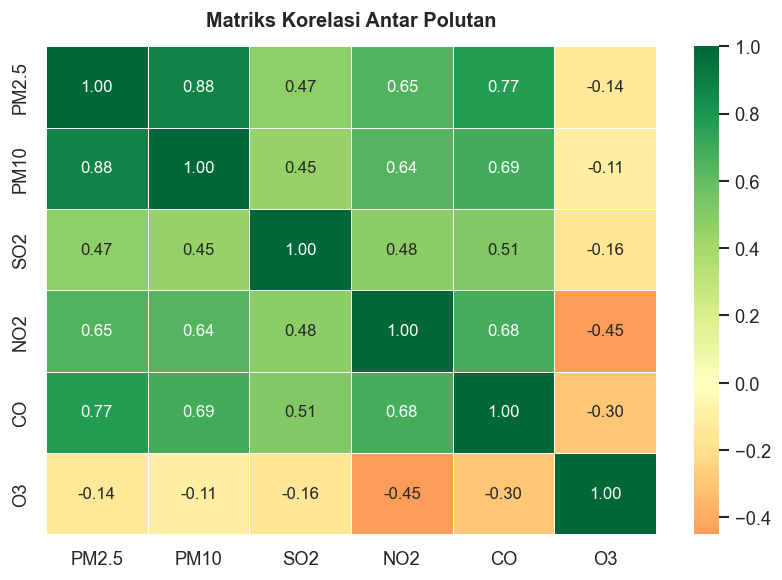

In [13]:
pollutant_columns = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
corr_matrix = df[pollutant_columns].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, ax=ax, linewidths=0.5, fmt='.2f', annot_kws={'size': 10})
ax.set_title('Matriks Korelasi Antar Polutan', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

**Insight:**
- Nilai rata-rata PM2.5 seluruh dataset sekitar 80 µg/m³, jauh melampaui batas aman dari WHO (15 µg/m³ rata-rata tahunan).
- PM2.5 berkorelasi sangat kuat dengan PM10 (r ≈ 0.88) dan CO (r ≈ 0.77), mengartikan bahwa mereka merupakan sumber emisi yang serupa (seperti pembakaran bahan bakar).
- O3 (ozon) berkorelasi negatif dengan PM2.5 dan polutan lain, karena ozon terbentuk melalui reaksi fotokimia yang lebih aktif saat polutan lain rendah (kondisi cerah, angin kencang).

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pada tahun dan musim apa rata-rata PM2.5 tertinggi terjadi di Beijing selama 2013–2017?

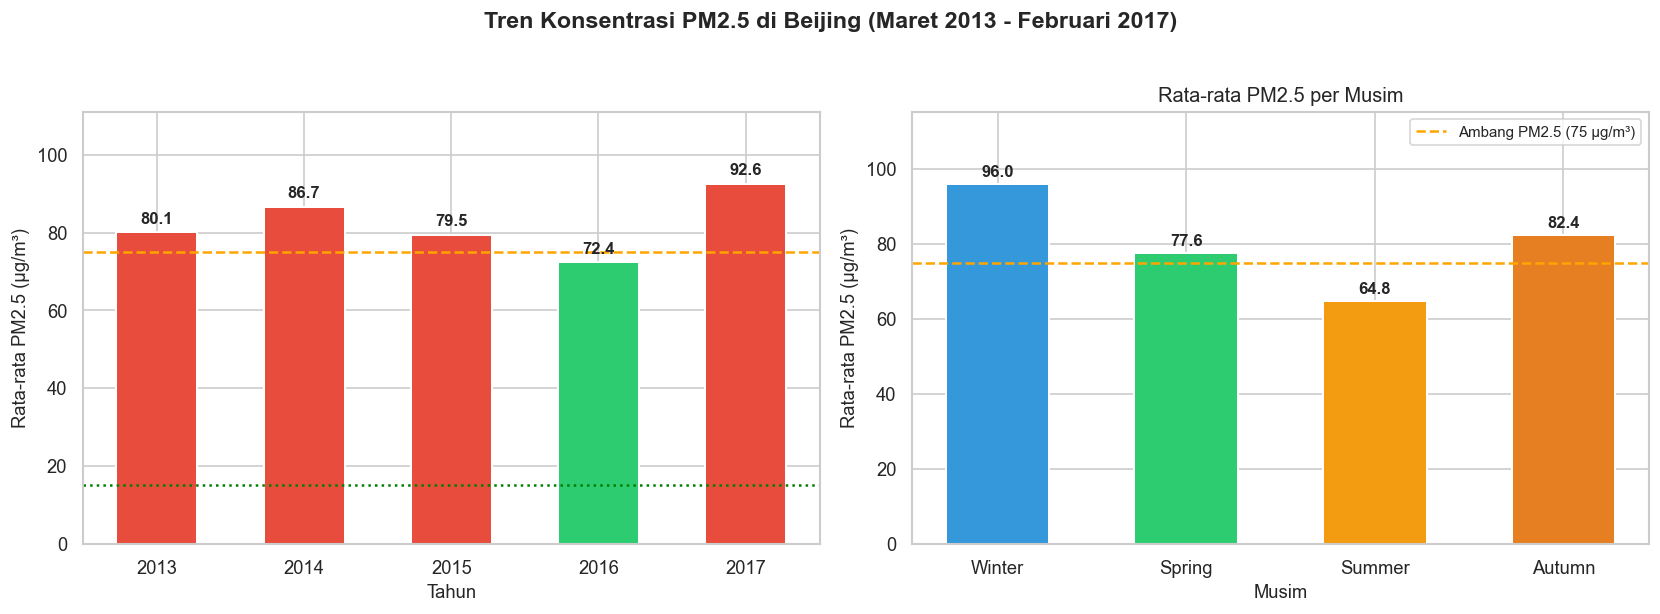

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tren Konsentrasi PM2.5 di Beijing (Maret 2013 - Februari 2017)', fontsize=14, fontweight='bold', y=1.02)

ax1 = axes[0]
yearly_mean = df.groupby('year')['PM2.5'].mean().reset_index()

colors_yr = ['#e74c3c' if v > 75 else '#2ecc71' for v in yearly_mean['PM2.5']]

bars = ax1.bar(yearly_mean['year'].astype(str), yearly_mean['PM2.5'], color=colors_yr, edgecolor='white', linewidth=1.2, width=0.55)
ax1.axhline(75, color='orange', linestyle='--', linewidth=1.5, label='Ambang PM2.5(75 µg/m³)')
ax1.axhline(15, color='green', linestyle=':', linewidth=1.5, label='Standar WHO (15 µg/m³)')

for bar, val in zip(bars, yearly_mean['PM2.5']):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5, f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xlabel('Tahun', fontsize=11)
ax1.set_ylabel('Rata-rata PM2.5 (µg/m³)', fontsize=11)
ax.set_title('Rata-rata PM2.5 per Tahun', fontsize=12)
ax.legend(fontsize=9)
ax1.set_ylim(0, max(yearly_mean['PM2.5']) * 1.2)



ax2 = axes[1]

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_colors = {'Winter': '#3498db', 'Spring': '#2ecc71', 'Summer': '#f39c12', 'Autumn': '#e67e22'}
seasonal_mean = df.groupby('season')['PM2.5'].mean().reindex(season_order).reset_index()

bars2 = ax2.bar(seasonal_mean['season'], seasonal_mean['PM2.5'], color=[season_colors[s] for s in seasonal_mean['season']], edgecolor='white', linewidth=1.2, width=0.55)
ax2.axhline(75, color='orange', linestyle='--', linewidth=1.5, label='Ambang PM2.5 (75 µg/m³)')

for bar, val in zip(bars2, seasonal_mean['PM2.5']):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.2, f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xlabel('Musim', fontsize=11)
ax2.set_ylabel('Rata-rata PM2.5 (µg/m³)', fontsize=11)
ax2.set_title('Rata-rata PM2.5 per Musim', fontsize=12)
ax2.legend(fontsize=9)
ax2.set_ylim(0, max(seasonal_mean['PM2.5']) * 1.2)

plt.tight_layout()
plt.savefig('dashboard/visual_pertanyaan1.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight Pertanyaan 1:**
- Selama periode **Maret 2013 – Februari 2017**, konsentrasi PM2.5 rata-rata tahunan di seluruh 12 stasiun Beijing secara konsisten melampaui ambang batas China sebesar 75 µg/m³ dan jauh di atas standar WHO sebesar 15 µg/m³, terkecuali pada Tahun 2016 yang berada sedikit di bawah ambang batas China.
- **Tahun 2017** mencatat rata-rata PM2.5 tertinggi sepanjang periode pengamatan. Terdapat tren penurunan dari 2015 hingga 2016 yang mengindikasikan dampak positif kebijakan pengendalian polusi, namun angka tersebut meningkat kembali pada 2017.
- Secara musiman, **Winter (musim dingin)** secara konsisten mencatat rata-rata PM2.5 tertinggi di antara keempat musim selama seluruh periode pengamatan, diduga kuat akibat meningkatnya penggunaan pemanas berbahan bakar batu bara. Sebaliknya, **Summer (musim panas)** mencatat rata-rata PM2.5 terendah, berkat curah hujan yang lebih tinggi dan angin yang lebih kencang yang membantu mengencerkan polutan.

### Pertanyaan 2: Stasiun mana yang memiliki rata-rata PM2.5 tertinggi dan terendah, serta berapa besar selisihnya selama 2013–2017?

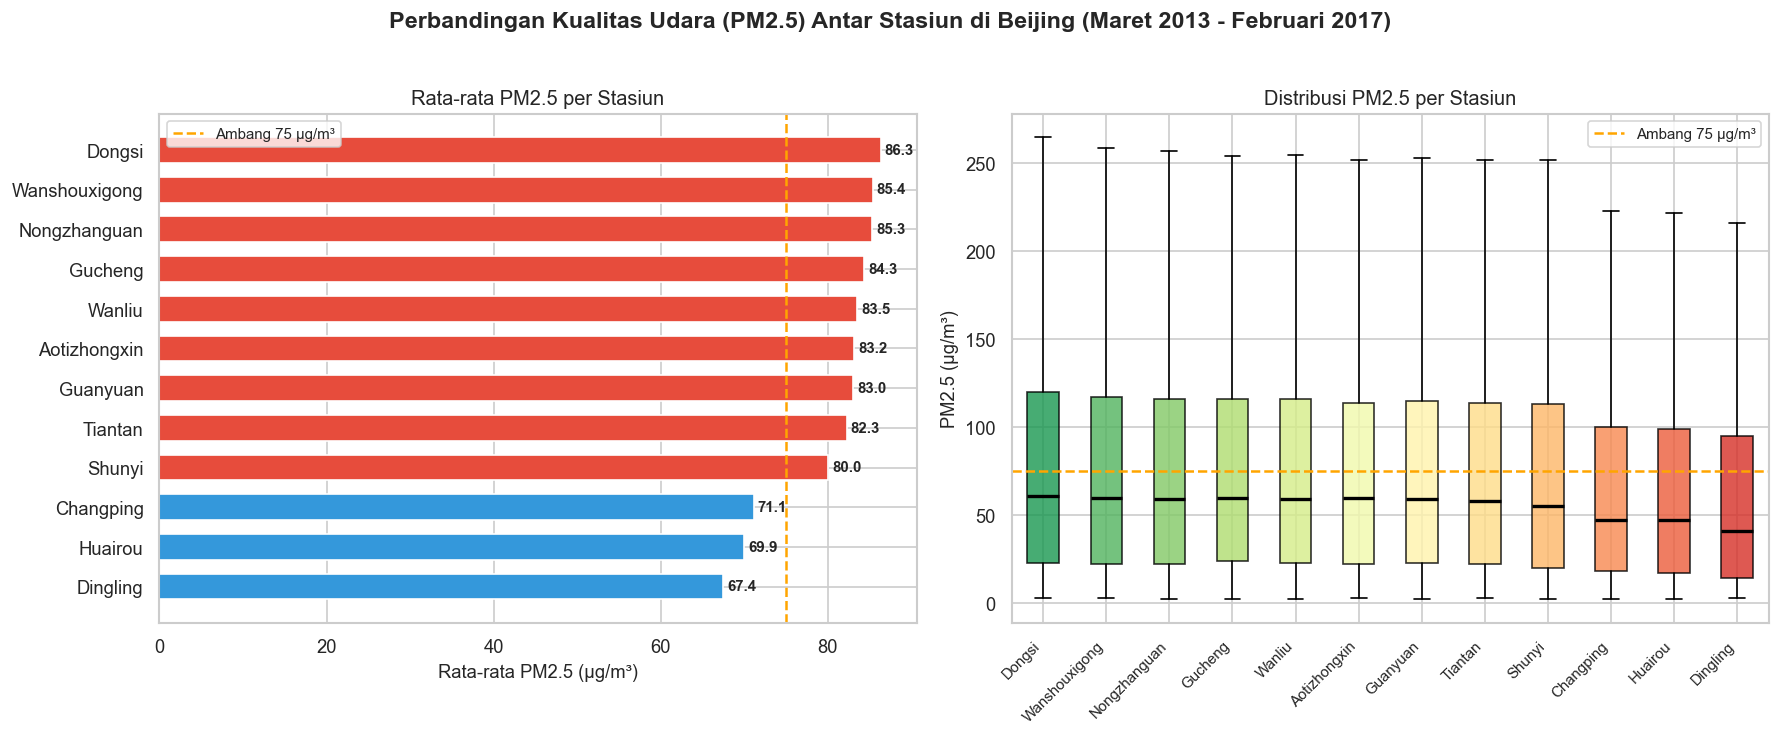

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Perbandingan Kualitas Udara (PM2.5) Antar Stasiun di Beijing (Maret 2013 - Februari 2017)', fontsize=14, fontweight='bold', y=1.02)

ax1 = axes[0]
stasiun_mean = df.groupby('station')['PM2.5'].mean().sort_values()
palette = ['#e74c3c' if v > 75 else '#3498db' for v in stasiun_mean.values]

bars = ax1.barh(stasiun_mean.index, stasiun_mean.values, color=palette, edgecolor='white', linewidth=1, height=0.65)
ax1.axvline(75, color='orange', linestyle='--', linewidth=1.5, label='Ambang 75 µg/m³')

for bar, val in zip(bars, stasiun_mean.values):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:.1f}', va='center', ha='left', fontsize=9, fontweight='bold')

ax1.set_xlabel('Rata-rata PM2.5 (µg/m³)', fontsize=11)
ax1.set_title('Rata-rata PM2.5 per Stasiun', fontsize=12)
ax1.legend(fontsize=9)


ax2 = axes[1]
stasiun_order_box = stasiun_mean.sort_values(ascending=False).index.tolist()
df_box = df[df['station'].isin(stasiun_order_box)]
df_box['station'] = pd.Categorical(df_box['station'], categories=stasiun_order_box, ordered=True)

bp = ax2.boxplot(
    [df_box[df_box['station'] == s]['PM2.5'].dropna().values for s in stasiun_order_box],
    vert=True, patch_artist=True, showfliers=False,
    medianprops=dict(color='black', linewidth=2)
)

colors_box = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(stasiun_order_box)))

for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax2.set_xticklabels(stasiun_order_box, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('PM2.5 (µg/m³)', fontsize=11)
ax2.set_title('Distribusi PM2.5 per Stasiun', fontsize=12)
ax2.axhline(75, color='orange', linestyle='--', linewidth=1.5, label='Ambang 75 µg/m³')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('dashboard/visual_pertanyaan2.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight Pertanyaan 2:**
- Selama periode **Maret 2013 – Februari 2017**, stasiun **Dongsi** mencatat rata-rata PM2.5 tertinggi, sementara stasiun **Dingling** mencatat rata-rata PM2.5 terendah di antara seluruh 12 stasiun pemantauan.
- Selisih rata-rata PM2.5 antara stasiun terpolusi (Dongsi) dan stasiun terbersih (Dingling) cukup signifikan, yang kemungkinan besar dipengaruhi oleh lokasi geografis: Dingling berada di kawasan pinggiran/pegunungan yang jauh dari pusat industri dan lalu lintas padat, sedangkan Dongsi terletak di zona pusat kota dengan aktivitas industri dan transportasi yang tinggi.
- Meskipun demikian, **hampir semua stasiun** rata-rata melampaui ambang batas China 75 µg/m³ selama periode pengamatan, menunjukkan bahwa permasalahan kualitas udara bersifat cukup merata di seluruh kota Beijing.

## Analisis Lanjutan: Clustering Kualitas Udara Berdasarkan Binning PM2.5

Pada bagian ini, saya akan menerapkan teknik **clustering berbasis Binning** untuk mengelompokkan setiap pengamatan ke dalam kategori kualitas udara berdasarkan konsentrasi PM2.5. Tujuannya adalah untuk memahami proporsi waktu tiap stasiun berada pada kondisi kualitas udara tertentu, sehingga dapat dijadikan dasar rekomendasi kebijakan. Kategorisasi mengacu pada standar AQI China.

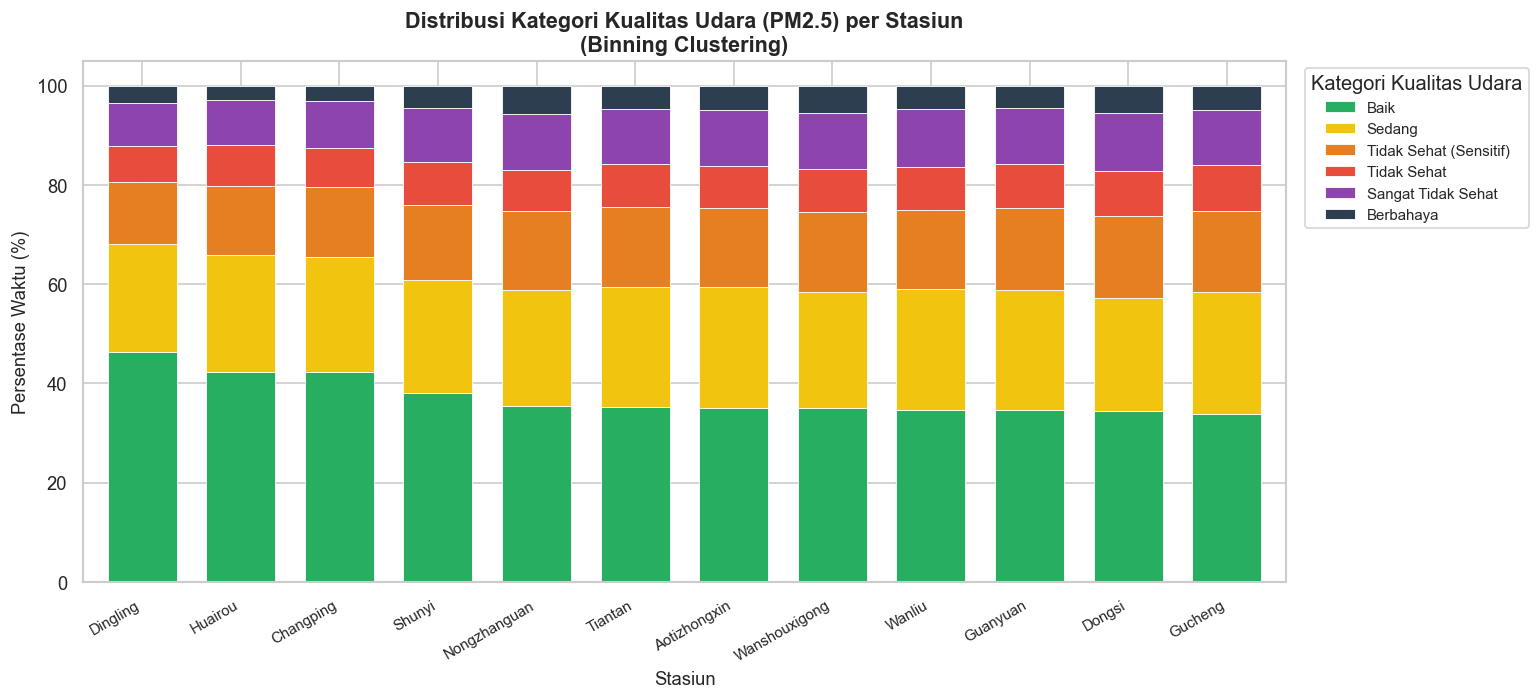

In [16]:
quality_order = ['Baik', 'Sedang', 'Tidak Sehat (Sensitif)', 'Tidak Sehat', 'Sangat Tidak Sehat', 'Berbahaya']
stasiun_quality = (df.groupby(['station', 'air_quality']).size().unstack(fill_value=0).reindex(columns=quality_order, fill_value=0))
stasiun_quality_pct = stasiun_quality.div(stasiun_quality.sum(axis=1), axis=0) * 100

stasiun_quality_pct_sorted = stasiun_quality_pct.sort_values('Baik', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
colors_cat = ['#27ae60', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad', '#2c3e50']

stasiun_quality_pct_sorted.plot(kind='bar', stacked=True, ax=ax, color=colors_cat, edgecolor='white', linewidth=0.5, width=0.7)

ax.set_xlabel('Stasiun', fontsize=11)
ax.set_ylabel('Persentase Waktu (%)', fontsize=11)
ax.set_title('Distribusi Kategori Kualitas Udara (PM2.5) per Stasiun\n(Binning Clustering)', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.legend(title='Kategori Kualitas Udara', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('dashboard/visual_clustering.png', bbox_inches='tight', dpi=150)
plt.show()

In [17]:
print("========================================")
print("Waktu Kualitas Udara 'Baik' per Stasiun")
print("========================================")
print(stasiun_quality_pct_sorted['Baik'].round(1).to_string())

Waktu Kualitas Udara 'Baik' per Stasiun
station
Dingling         46.4
Huairou          42.3
Changping        42.3
Shunyi           38.0
Nongzhanguan     35.5
Tiantan          35.2
Aotizhongxin     35.0
Wanshouxigong    34.9
Wanliu           34.7
Guanyuan         34.6
Dongsi           34.5
Gucheng          33.8


**Insight Analisis Lanjutan (Clustering Binning):**
- Stasiun **Dingling**, **Huairou**, dan **Changping** memiliki persentase waktu di kategori 'baik' tertinggi (sekitar 40% dari total jam pengamatan), menjadikannya stasiun dengan kualitas udara terbaik di kota Beijing.
- Stasiun **Dongsi** dan **Gucheng** memiliki proporsi kategori 'Berbahaya' dan 'Sangat Tidak Sehat' yang paling besar, menunjukkan tingkat risiko kesehatan yang lebih tinggi bagi warga sekitar.
- Secara keseluruhan, lebih dari separuh jam pengamatan di semua stasiun masuk kategori 'Sedang' atau lebih buruk, menekankan urgensi perbaikan kualitas udara di Beijing.

## Menyiapkan Data untuk Dashboard

In [18]:
df.to_csv('dashboard/main_data.csv', index=False)
print(f'main_data.csv disimpan dengan {len(df):,} baris dan {len(df.columns):,} kolom')

main_data.csv disimpan dengan 420,768 baris dan 21 kolom


## Conclusion

- **Conclution pertanyaan 1:** Selama periode Maret 2013 hingga Februari 2017, konsentrasi PM2.5 di Beijing menunjukkan tren penurunan dari 2015 hingga 2016, mengindikasikan efek positif dari kebijakan pengendalian polusi. **Tahun 2017 mencatat rata-rata PM2.5 tahunan tertinggi** sepanjang periode pengamatan. Secara musiman, **Winter (musim dingin) secara konsisten menjadi musim dengan rata-rata PM2.5 tertinggi** di setiap tahunnya akibat penggunaan pemanas batu bara, sementara Summer mencatat yang terendah. Temuan ini mengindikasikan perlunya kebijakan pengendalian emisi yang lebih ketat dan spesifik pada periode musim dingin.

- **Conclution pertanyaan 2:** Selama periode Maret 2013 hingga Februari 2017, terdapat perbedaan signifikan kualitas udara antar stasiun. **Stasiun Dongsi mencatat rata-rata PM2.5 tertinggi**, sementara **Stasiun Dingling mencatat yang terendah** di antara 12 stasiun. Selisih antara keduanya mencerminkan pengaruh lokasi geografis (pusat kota vs pinggiran/pegunungan) terhadap tingkat polusi. Namun demikian, hampir seluruh 12 stasiun rata-rata melampaui ambang batas aman China sebesar 75 µg/m³, sehingga diperlukan intervensi kesehatan masyarakat secara menyeluruh di seluruh wilayah Beijing.